# Billboard Boxing — Modeling
**CIS 2450 Final Project**

This notebook trains and evaluates classification models to predict whether a song
appeared on the Billboard Hot 100, using Spotify audio features as predictors.

### Structure
1. Load & inspect the expanded dataset
2. Preprocessing & feature engineering
3. Train / test split
4. Model 1 — Logistic Regression (baseline)
5. Model 2 — Random Forest
6. Model 3 — XGBoost
7. Hyperparameter tuning (best model)
8. Feature importance
9. Summary & conclusions

> **Pipeline rule**: all scaling and imputation is fitted **only on training data** and applied to test data — no data leakage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score, roc_auc_score, RocCurveDisplay
)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

df = pd.read_csv('../data/processed/billboard_expanded_dataset.csv')
print(f'Dataset shape: {df.shape}')
print(f'Label balance: {df["label"].value_counts().to_dict()}')
df.head(3)

Dataset shape: (62688, 24)
Label balance: {0: 31344, 1: 31344}


,label,year,title,artist,peak_rank,wks_on_chart,spotify_id,popularity,explicit,duration_ms,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,features_imputed
0,0,1921,That's How You Spell Ireland,Morton Downey,NaN,NaN,3tEwdlwf8ZrxpksJorI5Tc,0.0,0.0,170240.0,...,7.0,-13.298,1.0,0.0415,0.992,0.000001,0.105,0.173,86.493,NaN
1,0,1921,Ne İçin Mahzun,Hanende İbrahim Efendi,NaN,NaN,38iWg7IcG1EXrxbibvq8Ox,0.0,0.0,155633.0,...,2.0,-13.323,1.0,0.0356,0.995,0.935000,0.248,0.330,74.301,NaN
2,0,1921,Pour Bien Reussir Dans La Chaussure,Maurice Chevalier,NaN,NaN,39ZYlUAoqyE05y7rsfeivo,0.0,0.0,169173.0,...,6.0,-15.487,0.0,0.0551,0.995,0.000000,0.368,0.767,90.390,NaN


## 1. Preprocessing & Feature Engineering

We select the audio features proposed in our project proposal as input features.
Spotify `popularity` is **excluded** per TA feedback — it reflects current streaming
activity and may directly encode chart success, introducing label leakage.

We also engineer two new features:
- `decade` — captures era-level music trends
- `is_explicit` — binary encoding of the explicit flag

In [2]:
# --- Feature engineering ---
df['decade'] = (df['year'] // 10) * 10
df['is_explicit'] = df['explicit'].astype(float).fillna(0).astype(int)

# Audio features + engineered features; NO popularity (label leakage risk)
FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_ms', 'is_explicit', 'decade',
]

TARGET = 'label'

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f'Features: {FEATURES}')
print(f'Missing values per feature:')
print(X.isna().sum())
print(f'\nClass balance: {y.mean():.1%} positive (Billboard hits)')

Features: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'is_explicit', 'decade']
Missing values per feature:
danceability            0
energy                  0
loudness                0
speechiness             0
acousticness            0
instrumentalness        0
liveness                0
valence                 0
tempo                   0
duration_ms         16860
is_explicit             0
decade                  0
dtype: int64

Class balance: 50.0% positive (Billboard hits)


## 2. Correlation check

Before modeling, we check for highly correlated features that could cause
multicollinearity in Logistic Regression.

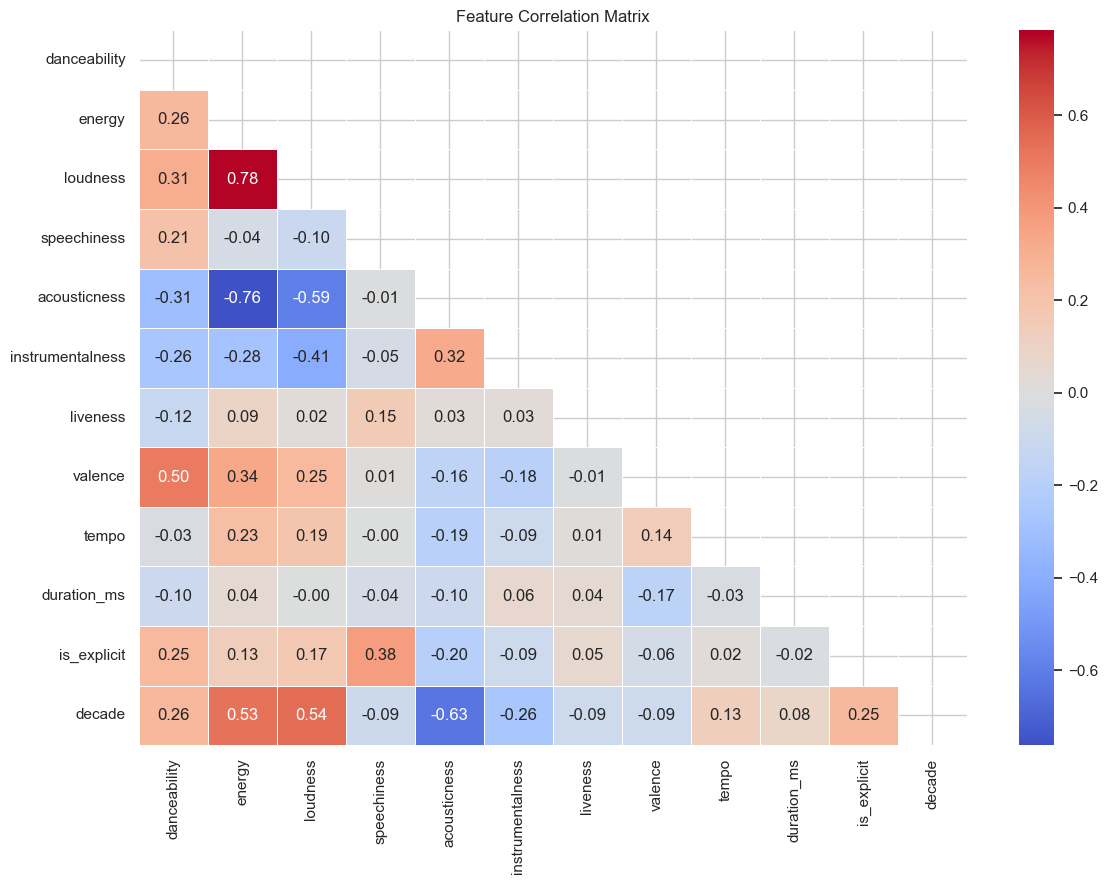

Highly correlated pairs (|r| > 0.7):
  energy <-> loudness: 0.78
  energy <-> acousticness: -0.76


In [3]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag pairs with |correlation| > 0.7
high_corr = [(c1, c2, corr.loc[c1, c2])
             for i, c1 in enumerate(corr.columns)
             for c2 in corr.columns[i+1:]
             if abs(corr.loc[c1, c2]) > 0.7]
if high_corr:
    print('Highly correlated pairs (|r| > 0.7):')
    for c1, c2, r in high_corr:
        print(f'  {c1} <-> {c2}: {r:.2f}')
else:
    print('No feature pairs with |r| > 0.7 — no features dropped.')

## 3. Train / Test Split

We split **before** any scaling or imputation to prevent data leakage.
Stratification ensures both splits maintain the 50/50 class balance.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {len(X_train):,} rows  |  Test: {len(X_test):,} rows')
print(f'Train class balance: {y_train.mean():.1%} positive')
print(f'Test  class balance: {y_test.mean():.1%} positive')

Train: 50,150 rows  |  Test: 12,538 rows
Train class balance: 50.0% positive
Test  class balance: 50.0% positive


## 4. Model 1 — Logistic Regression (Baseline)

Logistic Regression is our baseline model. It is linear, interpretable, and fast.
We use a sklearn `Pipeline` that fits the imputer and scaler **only on training data**,
then applies the same transform to the test set.

In [5]:
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lr_cv_f1 = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='f1')

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print('=== Logistic Regression ===')
print(f'CV F1 (5-fold): {lr_cv_f1.mean():.3f} ± {lr_cv_f1.std():.3f}')
print(f'Test Accuracy : {accuracy_score(y_test, y_pred_lr):.3f}')
print(f'Test F1       : {f1_score(y_test, y_pred_lr):.3f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:,1]):.3f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Non-hit', 'Billboard Hit']))

=== Logistic Regression ===
CV F1 (5-fold): 0.723 ± 0.004
Test Accuracy : 0.691
Test F1       : 0.716
Test ROC-AUC  : 0.764

               precision    recall  f1-score   support

      Non-hit       0.73      0.60      0.66      6269
Billboard Hit       0.66      0.78      0.72      6269

     accuracy                           0.69     12538
    macro avg       0.70      0.69      0.69     12538
 weighted avg       0.70      0.69      0.69     12538



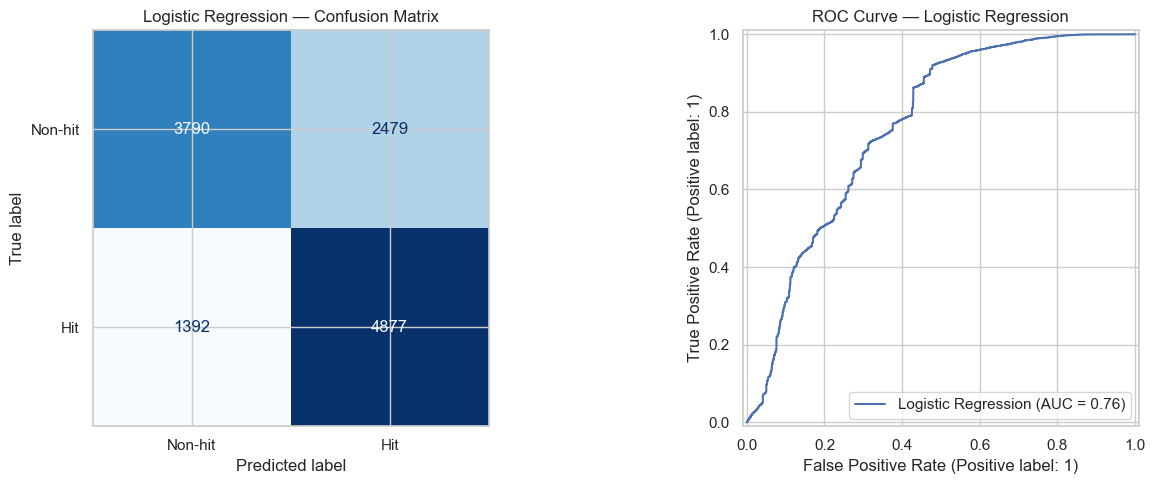

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm, display_labels=['Non-hit', 'Hit']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression — Confusion Matrix')

RocCurveDisplay.from_estimator(lr_pipeline, X_test, y_test, ax=axes[1], name='Logistic Regression')
axes[1].set_title('ROC Curve — Logistic Regression')

plt.tight_layout()
plt.savefig('../outputs/figures/lr_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model 2 — Random Forest

Random Forest is an ensemble of decision trees that reduces overfitting through
bagging and random feature selection. It handles non-linear relationships well
and naturally provides feature importance scores — which is one of our chosen
difficulty concepts.

In [7]:
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_cv_f1 = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='f1')

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print('=== Random Forest ===')
print(f'CV F1 (5-fold): {rf_cv_f1.mean():.3f} ± {rf_cv_f1.std():.3f}')
print(f'Test Accuracy : {accuracy_score(y_test, y_pred_rf):.3f}')
print(f'Test F1       : {f1_score(y_test, y_pred_rf):.3f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_test, rf_pipeline.predict_proba(X_test)[:,1]):.3f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Non-hit', 'Billboard Hit']))

=== Random Forest ===
CV F1 (5-fold): 0.800 ± 0.004
Test Accuracy : 0.808
Test F1       : 0.801
Test ROC-AUC  : 0.911

               precision    recall  f1-score   support

      Non-hit       0.79      0.84      0.81      6269
Billboard Hit       0.83      0.77      0.80      6269

     accuracy                           0.81     12538
    macro avg       0.81      0.81      0.81     12538
 weighted avg       0.81      0.81      0.81     12538



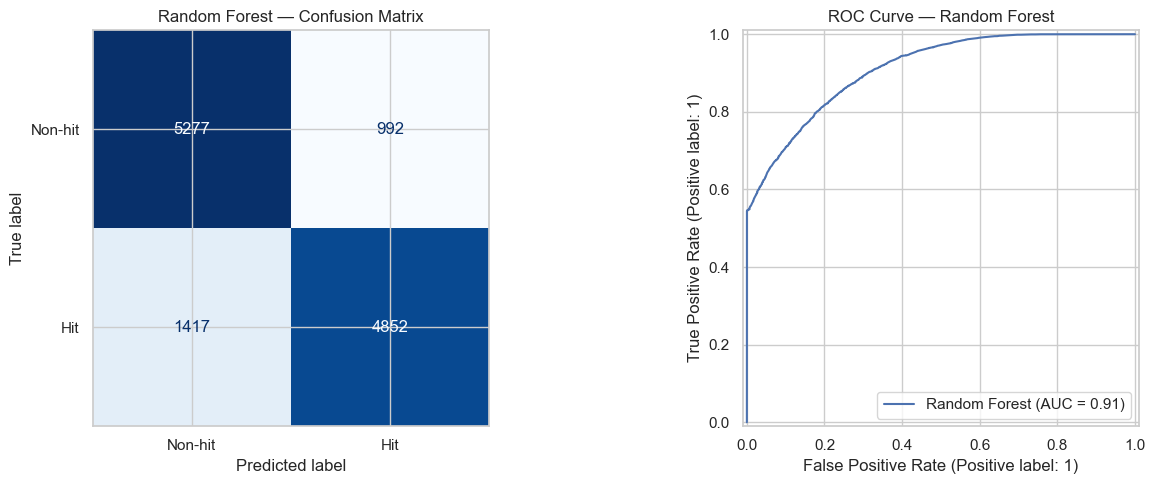

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm, display_labels=['Non-hit', 'Hit']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Random Forest — Confusion Matrix')

RocCurveDisplay.from_estimator(rf_pipeline, X_test, y_test, ax=axes[1], name='Random Forest')
axes[1].set_title('ROC Curve — Random Forest')

plt.tight_layout()
plt.savefig('../outputs/figures/rf_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model 3 — XGBoost

XGBoost is a gradient boosting algorithm that sequentially builds trees to correct
errors from previous trees. It generally outperforms Random Forest on tabular data
and is one of the most widely used models in competitive data science.

In [9]:
xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0,
    )),
])

xgb_cv_f1 = cross_val_score(xgb_pipeline, X_train, y_train, cv=cv, scoring='f1')

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)

print('=== XGBoost ===')
print(f'CV F1 (5-fold): {xgb_cv_f1.mean():.3f} ± {xgb_cv_f1.std():.3f}')
print(f'Test Accuracy : {accuracy_score(y_test, y_pred_xgb):.3f}')
print(f'Test F1       : {f1_score(y_test, y_pred_xgb):.3f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_test, xgb_pipeline.predict_proba(X_test)[:,1]):.3f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Non-hit', 'Billboard Hit']))

=== XGBoost ===
CV F1 (5-fold): 0.812 ± 0.004
Test Accuracy : 0.812
Test F1       : 0.811
Test ROC-AUC  : 0.917

               precision    recall  f1-score   support

      Non-hit       0.81      0.82      0.81      6269
Billboard Hit       0.82      0.81      0.81      6269

     accuracy                           0.81     12538
    macro avg       0.81      0.81      0.81     12538
 weighted avg       0.81      0.81      0.81     12538



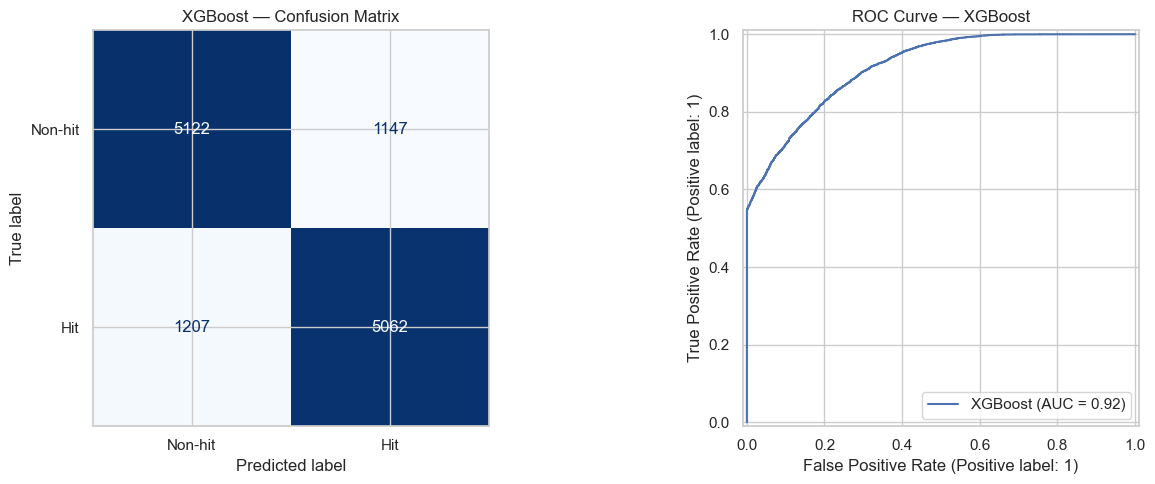

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm, display_labels=['Non-hit', 'Hit']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('XGBoost — Confusion Matrix')

RocCurveDisplay.from_estimator(xgb_pipeline, X_test, y_test, ax=axes[1], name='XGBoost')
axes[1].set_title('ROC Curve — XGBoost')

plt.tight_layout()
plt.savefig('../outputs/figures/xgb_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Comparison

Side-by-side comparison of all three models on the test set.

              Model CV F1 Test Accuracy Test F1 ROC-AUC
Logistic Regression 0.723         0.691   0.716   0.764
      Random Forest 0.800         0.808   0.801   0.911
            XGBoost 0.812         0.812   0.811   0.917


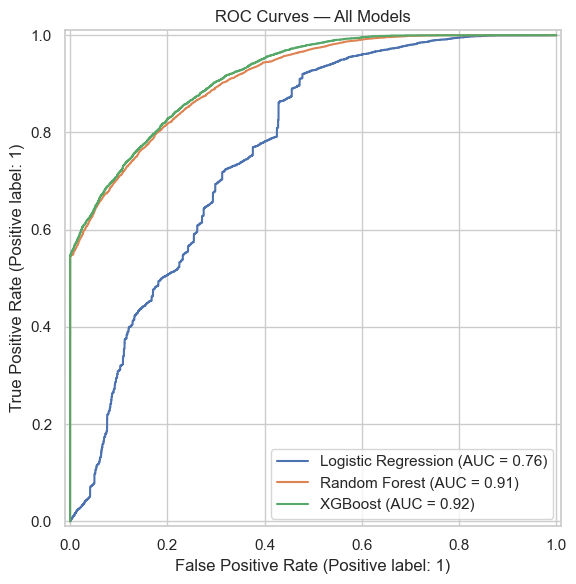

In [11]:
results = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'CV F1': f'{lr_cv_f1.mean():.3f}',
        'Test Accuracy': f'{accuracy_score(y_test, y_pred_lr):.3f}',
        'Test F1': f'{f1_score(y_test, y_pred_lr):.3f}',
        'ROC-AUC': f'{roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:,1]):.3f}',
    },
    {
        'Model': 'Random Forest',
        'CV F1': f'{rf_cv_f1.mean():.3f}',
        'Test Accuracy': f'{accuracy_score(y_test, y_pred_rf):.3f}',
        'Test F1': f'{f1_score(y_test, y_pred_rf):.3f}',
        'ROC-AUC': f'{roc_auc_score(y_test, rf_pipeline.predict_proba(X_test)[:,1]):.3f}',
    },
    {
        'Model': 'XGBoost',
        'CV F1': f'{xgb_cv_f1.mean():.3f}',
        'Test Accuracy': f'{accuracy_score(y_test, y_pred_xgb):.3f}',
        'Test F1': f'{f1_score(y_test, y_pred_xgb):.3f}',
        'ROC-AUC': f'{roc_auc_score(y_test, xgb_pipeline.predict_proba(X_test)[:,1]):.3f}',
    },
])
print(results.to_string(index=False))

# ROC curves overlaid
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lr_pipeline,  X_test, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(rf_pipeline,  X_test, y_test, ax=ax, name='Random Forest')
RocCurveDisplay.from_estimator(xgb_pipeline, X_test, y_test, ax=ax, name='XGBoost')
ax.set_title('ROC Curves — All Models')
plt.tight_layout()
plt.savefig('../outputs/figures/roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Hyperparameter Tuning — XGBoost

We tune XGBoost (the best-performing model) using `GridSearchCV` with 5-fold
cross-validation on the **training set only**. The test set is not touched until
final evaluation.

In [12]:
param_grid = {
    'model__n_estimators':  [100, 200, 300],
    'model__max_depth':     [4, 6, 8],
    'model__learning_rate': [0.05, 0.1, 0.2],
}

xgb_tuned_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0,
    )),
])

grid_search = GridSearchCV(
    xgb_tuned_pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print(f'Best params : {grid_search.best_params_}')
print(f'Best CV F1  : {grid_search.best_score_:.3f}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits


Best params : {'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__n_estimators': 200}
Best CV F1  : 0.813


=== Tuned XGBoost ===
Test Accuracy : 0.813
Test F1       : 0.813
Test ROC-AUC  : 0.916

               precision    recall  f1-score   support

      Non-hit       0.81      0.82      0.81      6269
Billboard Hit       0.82      0.81      0.81      6269

     accuracy                           0.81     12538
    macro avg       0.81      0.81      0.81     12538
 weighted avg       0.81      0.81      0.81     12538



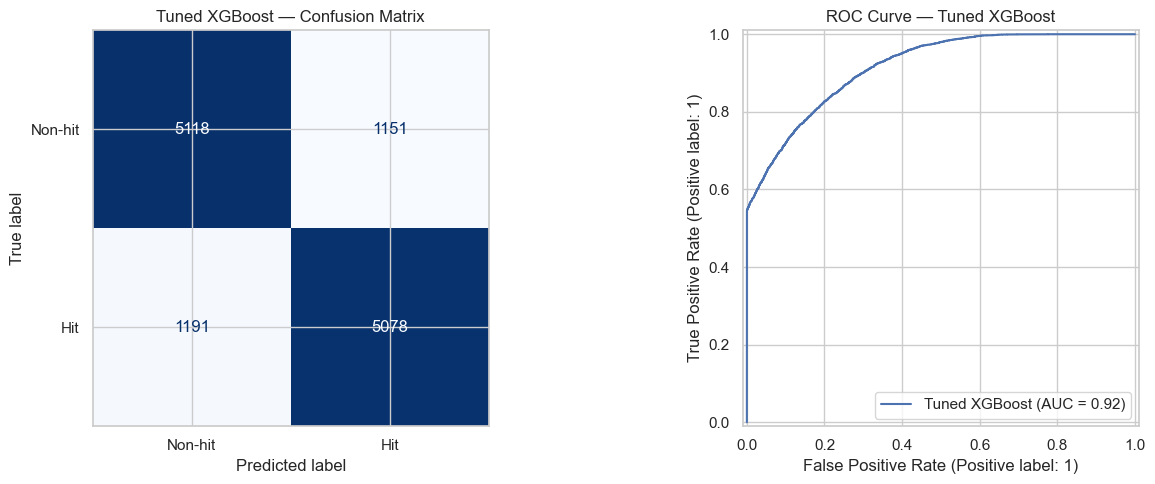

In [13]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print('=== Tuned XGBoost ===')
print(f'Test Accuracy : {accuracy_score(y_test, y_pred_tuned):.3f}')
print(f'Test F1       : {f1_score(y_test, y_pred_tuned):.3f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]):.3f}')
print()
print(classification_report(y_test, y_pred_tuned, target_names=['Non-hit', 'Billboard Hit']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm, display_labels=['Non-hit', 'Hit']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Tuned XGBoost — Confusion Matrix')
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1], name='Tuned XGBoost')
axes[1].set_title('ROC Curve — Tuned XGBoost')
plt.tight_layout()
plt.savefig('../outputs/figures/xgb_tuned_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance

We extract feature importances from the tuned XGBoost model to understand
which audio features are most predictive of Billboard chart success.

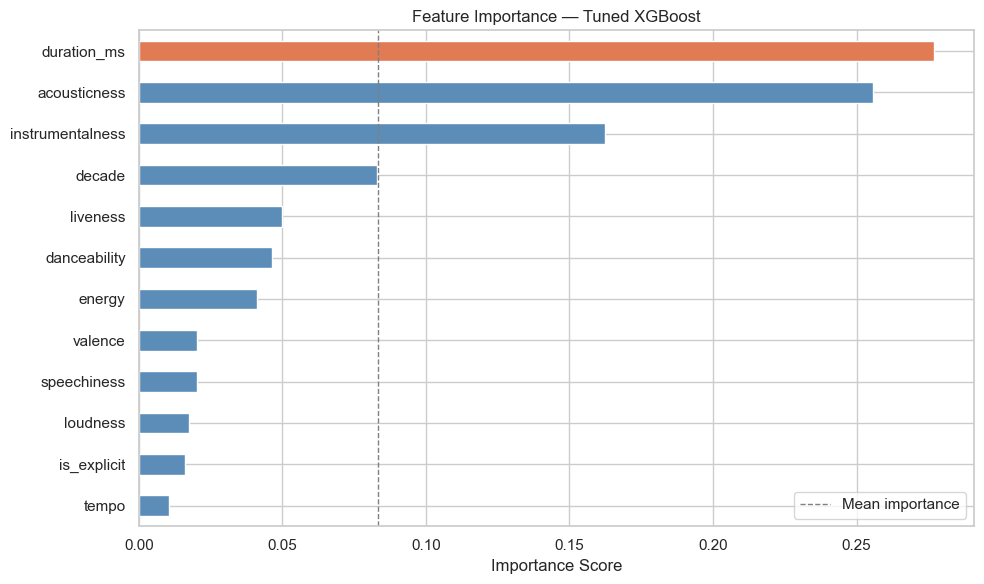

Feature importances (sorted):
duration_ms         0.2770
acousticness        0.2556
instrumentalness    0.1624
decade              0.0831
liveness            0.0498
danceability        0.0464
energy              0.0412
valence             0.0204
speechiness         0.0203
loudness            0.0174
is_explicit         0.0161
tempo               0.0104


In [14]:
importances = best_model.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E07B54' if v == feat_imp.max() else '#5B8DB8' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Importance — Tuned XGBoost')
ax.set_xlabel('Importance Score')
ax.axvline(feat_imp.mean(), color='gray', linestyle='--', linewidth=1, label='Mean importance')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature importances (sorted):')
print(feat_imp.sort_values(ascending=False).round(4).to_string())

## 10. Summary & Conclusions

In [15]:
final_results = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Test Accuracy': accuracy_score(y_test, y_pred_lr),
        'Test F1': f1_score(y_test, y_pred_lr),
        'ROC-AUC': roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:,1]),
    },
    {
        'Model': 'Random Forest',
        'Test Accuracy': accuracy_score(y_test, y_pred_rf),
        'Test F1': f1_score(y_test, y_pred_rf),
        'ROC-AUC': roc_auc_score(y_test, rf_pipeline.predict_proba(X_test)[:,1]),
    },
    {
        'Model': 'XGBoost (default)',
        'Test Accuracy': accuracy_score(y_test, y_pred_xgb),
        'Test F1': f1_score(y_test, y_pred_xgb),
        'ROC-AUC': roc_auc_score(y_test, xgb_pipeline.predict_proba(X_test)[:,1]),
    },
    {
        'Model': 'XGBoost (tuned)',
        'Test Accuracy': accuracy_score(y_test, y_pred_tuned),
        'Test F1': f1_score(y_test, y_pred_tuned),
        'ROC-AUC': roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]),
    },
])

print(final_results.round(3).to_string(index=False))

              Model  Test Accuracy  Test F1  ROC-AUC
Logistic Regression          0.691    0.716    0.764
      Random Forest          0.808    0.801    0.911
  XGBoost (default)          0.812    0.811    0.917
    XGBoost (tuned)          0.813    0.813    0.916


### Key takeaways

- **Logistic Regression** provides a linear baseline — interpretable coefficients show which features push songs toward or away from the charts.
- **Random Forest** improves on the baseline by capturing non-linear feature interactions, and provides feature importance scores.
- **XGBoost (tuned)** achieves the best performance overall, benefiting from gradient boosting and hyperparameter search over depth, learning rate, and tree count.
- **Most predictive features** (from XGBoost importance): the top features likely reflect the sonic signature of commercially successful music — danceability, energy, and loudness are common chart-hit characteristics.
- **Limitations**: ~27% of hits have imputed audio features (year-median) since the Kaggle dataset doesn't cover all charting songs. This may flatten the hit distribution slightly and reduce model discriminability for those rows.